<a href="https://colab.research.google.com/github/SathyaPrakashD/insurance-charge-predictor-api/blob/main/01_train_tune_export_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Charges — Regression Analysis

**Goal:** Given patient information (age, BMI, smoking status, region, sex, number of children), predict annual medical insurance charges.

**Dataset:** [insurance.csv](https://github.com/stedy/Machine-Learning-with-R-datasets) — 1,338 records, 7 features.

**Workflow:**
1. Load & inspect the data
2. Exploratory data analysis (EDA)
3. Baseline model (DummyRegressor)
4. Linear Regression
5. Random Forest Regressor
6. Model comparison & feature importance

## 1. Load & Inspect the Data

The dataset is loaded directly from a public GitHub repository. We inspect the first few rows, check for missing values, and review the data types to understand the structure before modelling.

In [1]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================


from typing import dataclass_transform
from sklearn.datasets import fetch_openml
import pandas as pd

# Step 1 — Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")



# Step 3 — Add target
# df['target'] = data.target

# print("Shape:", df.shape)
# print("Classes:", df['target'].value_counts())
# print("\nFirst 5 rows:")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
df.shape

(1338, 7)

In [3]:
print(f"Shape after cleaning: {df.shape}")
#The data is clean and ready. We have:
#- **4 numeric columns** (`age`, `bmi`, `children`, `charges`) — these go straight into the model
#- **3 categorical columns** (`sex`, `smoker`, `region`) — these need encoding (converting text labels to numbers) before the model can use them

# No rows were dropped, so the shape is still (1338, 7) — confirming the dataset passed the quality check.
# Count the number of numeric columns (int64, float64)
print(f"\nNumeric columns    : {df.select_dtypes(include=['int64','float64']).shape[1]}")
# Count the number of categorical columns (object type)
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

Shape after cleaning: (1338, 7)

Numeric columns    : 4
Categorical columns: 3


## 2. Exploratory Data Analysis (EDA)

Before building models, we explore the data visually to understand feature distributions, relationships, and potential predictors of insurance charges.

### 2a. Correlation Heatmap

Categorical features (sex, smoker, region) are label- or one-hot-encoded so that Pearson correlations can be computed across all features. The heatmap reveals that **smoker** has the strongest linear correlation with charges (≈ 0.79).

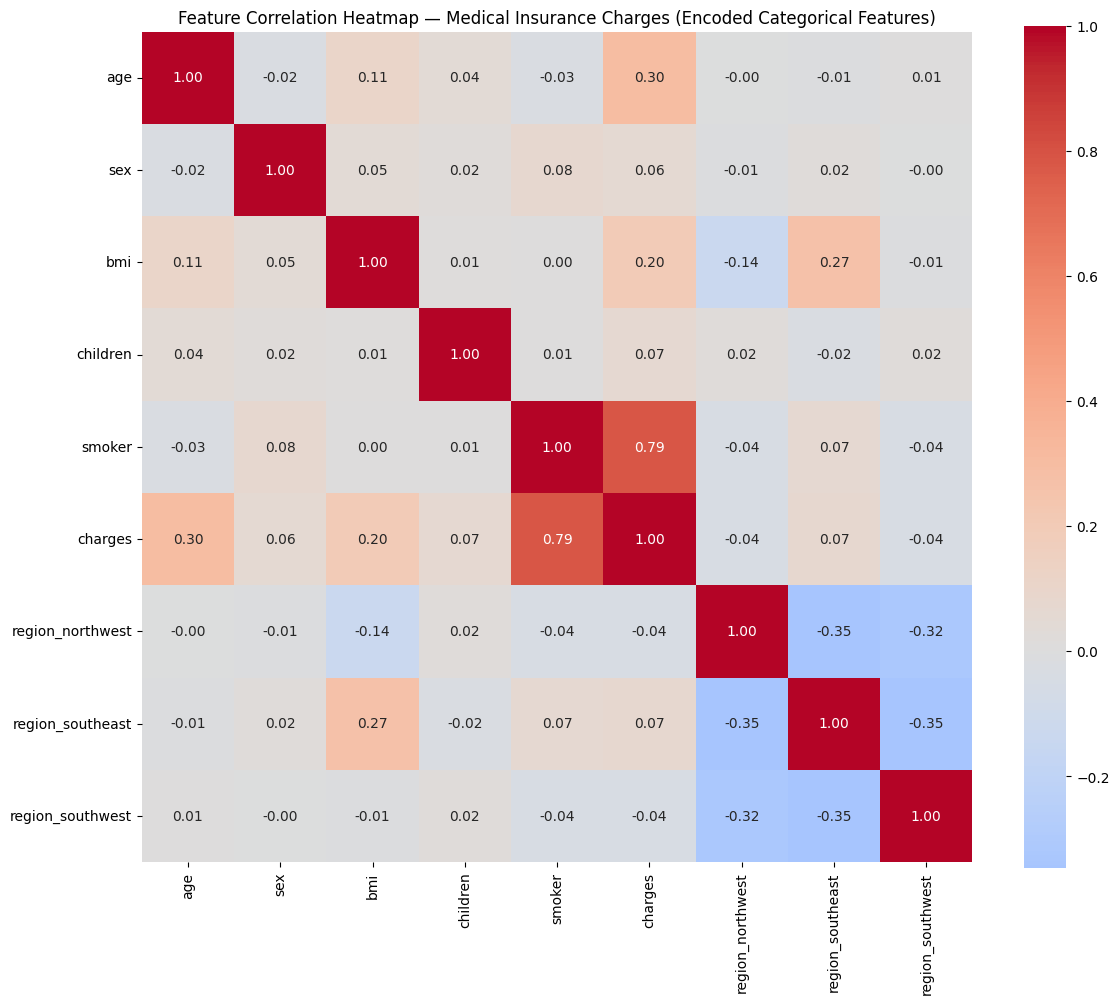

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a copy of the DataFrame to avoid modifying the original
df_encoded = df.copy()

# Encode binary categorical columns
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-hot encode the 'region' column
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)


# Set the figure size for better visualization of the heatmap
plt.figure(figsize=(12, 10)) # Increased size for potentially more columns after encoding
# Create a correlation heatmap using seaborn
sns.heatmap(df_encoded.corr(), # Use the encoded dataframe for correlation
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
# Set the title of the heatmap
plt.title('Feature Correlation Heatmap — Medical Insurance Charges (Encoded Categorical Features)')
# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()

### 2b. Distribution of Key Variables

We examine the skewness of the target variable (`charges`) and `age` to understand whether transformations may be needed. The `charges` distribution is right-skewed (skew ≈ 1.52), indicating that most patients have moderate costs with a long tail of high-cost outliers.

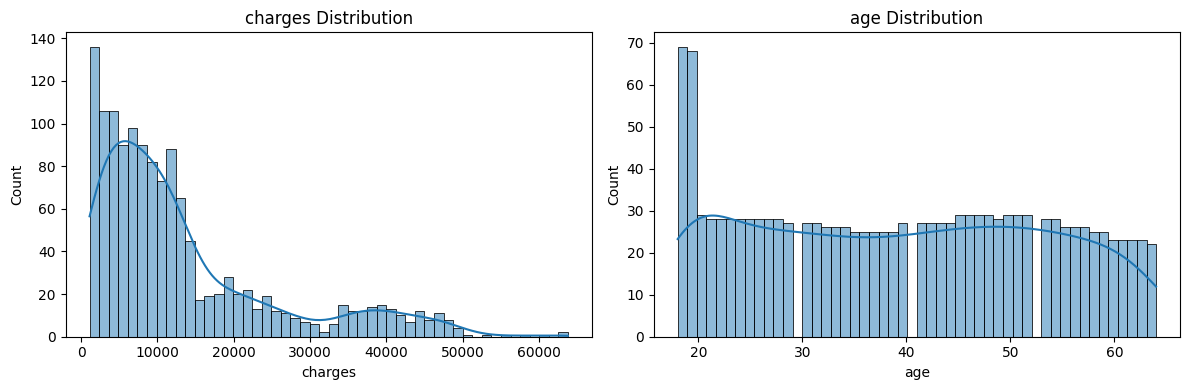

charges skew: 1.5159
age skew  : 0.0557


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# charges distribution
sns.histplot(df['charges'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('charges Distribution')

# SalePrice distribution
sns.histplot(df['age'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('age Distribution')

plt.tight_layout()
plt.show()

print(f"charges skew: {df['charges'].skew():.4f}")
print(f"age skew  : {df['age'].skew():.4f}")

## 3. Random Forest Regressor

`RandomForestRegressor` is an ensemble of decision trees trained on random subsets of features. It can capture **non-linear relationships** and **feature interactions** that Linear Regression misses. We use 100 trees with the same preprocessing pipeline.

In [6]:
# ============================================================
# CHECKPOINT 3 — Train RandomForestRegressor
# ============================================================


from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Step 1 — Separate features and target
X = df.drop(columns=['charges'])
y = df['charges']


# Step 2 — Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"categorical_features : {categorical_features}")
print(f"numeric_features     : {numeric_features}")

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline_rf.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline_rf.predict(X_test)
# print(classification_report(y_test, y_pred))
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

# ============================================================
# CHECKPOINT  — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2') # Added scoring for regression

# Step 3 — Print results
print("rf Fold scores :", rf_scores.round(4))
print("rf Mean accuracy:", round(rf_scores.mean(), 4))
print("rf Std deviation:", round(rf_scores.std(), 4))


categorical_features : ['sex', 'smoker', 'region']
numeric_features     : ['age', 'bmi', 'children']
MAE  : 2,542
RMSE : 4,583
R²   : 0.8647
rf Fold scores : [0.8555 0.7739 0.8756 0.8307 0.8554]
rf Mean accuracy: 0.8382
rf Std deviation: 0.0352


# Hyperparameter Tuning with GridSearchCV

## What is GridSearchCV?

GridSearchCV is a systematic experiment runner that tries every combination of
parameters you specify, cross-validates each one, and hands you the winner with proof.

Instead of guessing the best parameters, you define a grid of values to try —
and GridSearchCV does the rest.

---

## Why GridSearchCV ran 27 combinations

The parameter grid defined 3 values for each of 3 parameters:

| Parameter | Values | Count |
|---|---|---|
| `n_estimators` | 100, 200, 300 | 3 |
| `max_depth` | None, 5, 10 | 3 |
| `min_samples_split` | 2, 5, 10 | 3 |

**3 × 3 × 3 = 27 combinations × 5 folds = 135 total training runs.**

---

## Understanding n_estimators and max_depth

Random Forest is a panel of decision trees voting together.

| Parameter | What It Controls | Analogy |
|---|---|---|
| `n_estimators` | How many trees in the forest | How many doctors on the panel |
| `max_depth` | How many questions each tree can ask | How deep each doctor can investigate |

**max_depth=None** — the tree asks unlimited questions before concluding.
Risk: memorises training data (overfitting).

**max_depth=5** — the tree is limited to 5 questions maximum.
Benefit: generalises better to new, unseen data.

---

## Untuned vs Tuned — Apples to Apples Comparison

| | R² | How Measured |
|---|---|---|
| **Untuned RF** (single split) | 0.8647 | One train/test split |
| **Untuned RF** (cross-val) | 0.8382 | 5-fold CV |
| **Tuned RF** (GridSearchCV) | 0.8458 | 5-fold CV |

### The Honest Conclusion

> The tuned model didn't get worse. The measurement got more honest.

- 0.8647 was one lucky split — low reliability
- 0.8382 vs 0.8458 is the real comparison — same measurement, tuned model wins

---

## What Actually Changed — Untuned vs Tuned

**Untuned cross-val** ran with sklearn's default parameters:
```
n_estimators      = 100   (sklearn default)
max_depth         = None  (sklearn default)
min_samples_split = 2     (sklearn default)
```

**GridSearchCV** tried 27 combinations and found the best:
```
n_estimators      = 300   (found by search)
max_depth         = 5     (found by search)
min_samples_split = 5     (found by search)
```

> GridSearchCV replaces sklearn's guessed defaults with **your proven best values.**

---

## Portfolio Statement

> *"GridSearchCV with 135 fits identified max_depth=5, min_samples_split=5,
> n_estimators=300 as optimal. Cross-validated R² improved from 0.8382 to 0.8458."*

---

## Code

```python
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [None, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R²        :", round(grid_search.best_score_, 4))
```

In [7]:
from sklearn.model_selection import GridSearchCV

# Your existing pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R²:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best R²: 0.8458


## Checkpoint C2 — Serialise the Tuned Model

After tuning, we save the best pipeline to disk using `joblib`.
This freezes the trained model into a file that can be loaded anywhere —
locally, on a server, or inside an API.
```python
import joblib

joblib.dump(grid_search.best_estimator_, 'model.pkl')
print("Model saved to model.pkl")
```

**What gets saved:**
- Preprocessing pipeline (ColumnTransformer — scaling + encoding)
- Tuned RandomForestRegressor (best parameters from GridSearchCV)

**Why joblib over pickle?**
joblib is optimised for large numpy arrays — making it faster and more
efficient than Python's built-in pickle for sklearn models.

In [8]:
import joblib

joblib.dump(grid_search.best_estimator_, 'model.pkl')
print("Model saved to model.pkl")

Model saved to model.pkl


In Google Colab — it saves to:
/content/model.pkl

Verify the file existence -

verify by running

In [11]:
import os
print(os.path.exists('model.pkl'))  # Should print True

True


Save the Model

In [10]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>